<a href="https://colab.research.google.com/github/sanjaypras/crispr_pred/blob/main/notebooks/genome_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install dython

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import numpy as np


In [43]:
df = pd.read_csv('V1_suppl_data.txt', sep='\t')

In [44]:
df.head(20)

,Spacer Sequence,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Transcript,Gene Symbol,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Annotation,Activity,Percent Rank
0,CTGATCTCCAGATATGACCA,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,sense,ENSMUST00000182755,CD45,242,2.0,0.18,CDS,2.308903,0.346278
1,TGATCTCCAGATATGACCAT,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,sense,ENSMUST00000182755,CD45,243,2.0,0.18,CDS,2.530273,0.365696
2,AAGTTTGAGCCACAAACCCA,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,antisense,ENSMUST00000182755,CD45,248,4.0,0.35,CDS,4.098996,0.857605
3,CAGATATGACCATGGGTTTG,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,sense,ENSMUST00000182755,CD45,250,5.0,0.44,CDS,3.807251,0.705502
4,GGGTTTGTGGCTCAAACTTC,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,sense,ENSMUST00000182755,CD45,263,9.0,0.80,CDS,1.585304,0.258900
5,TGGCTCAAACTTCTGGCCTT,TTTGTGGCTCAAACTTCTGGCCTTTGGATTTGCC,sense,ENSMUST00000182755,CD45,270,11.0,0.97,CDS,-3.768976,0.006472
6,GTCCAGAAGGGCAAATCCAA,CTGTGTCCAGAAGGGCAAATCCAAAGGCCAGAAG,antisense,ENSMUST00000182755,CD45,275,13.0,1.15,CDS,3.816749,0.711974
7,GGCCTTTGGATTTGCCCTTC,TTCTGGCCTTTGGATTTGCCCTTCTGGACACAGA,sense,ENSMUST00000182755,CD45,284,16.0,1.42,CDS,1.247028,0.207120
8,AAAGACTTCTGTGTCCAGAA,TGACAAAGACTTCTGTGTCCAGAAGGGCAAATCC,antisense,ENSMUST00000182755,CD45,287,17.0,1.50,CDS,4.559195,0.996764
9,CAAAGACTTCTGTGTCCAGA,GTGACAAAGACTTCTGTGTCCAGAAGGGCAAATC,antisense,ENSMUST00000182755,CD45,288,17.0,1.50,CDS,3.497215,0.569579


<Axes: >

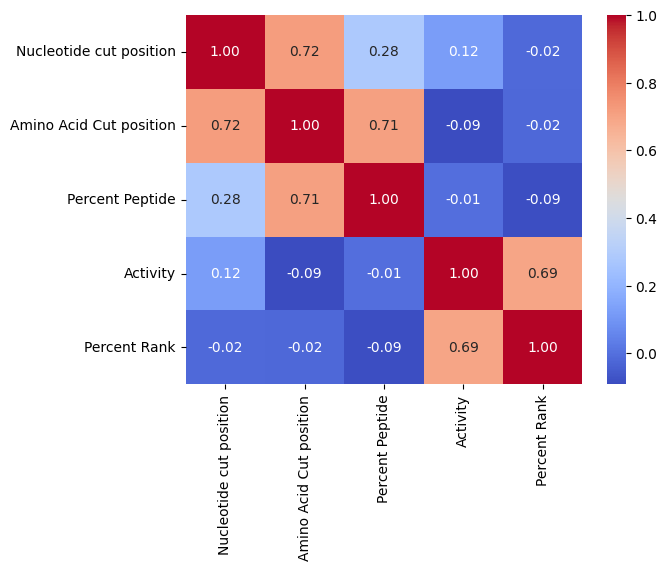

In [45]:
df_no_nums = df.drop(columns=['Spacer Sequence', 'Extended Spacer(NNNN[20nt]NGGNNNNNNN)', 'Strand', 'Transcript', 'Gene Symbol', 'Annotation'])
sns.heatmap(df_no_nums.corr(), annot=True, fmt=".2f", cmap="coolwarm")

<Figure size 1200x1000 with 0 Axes>

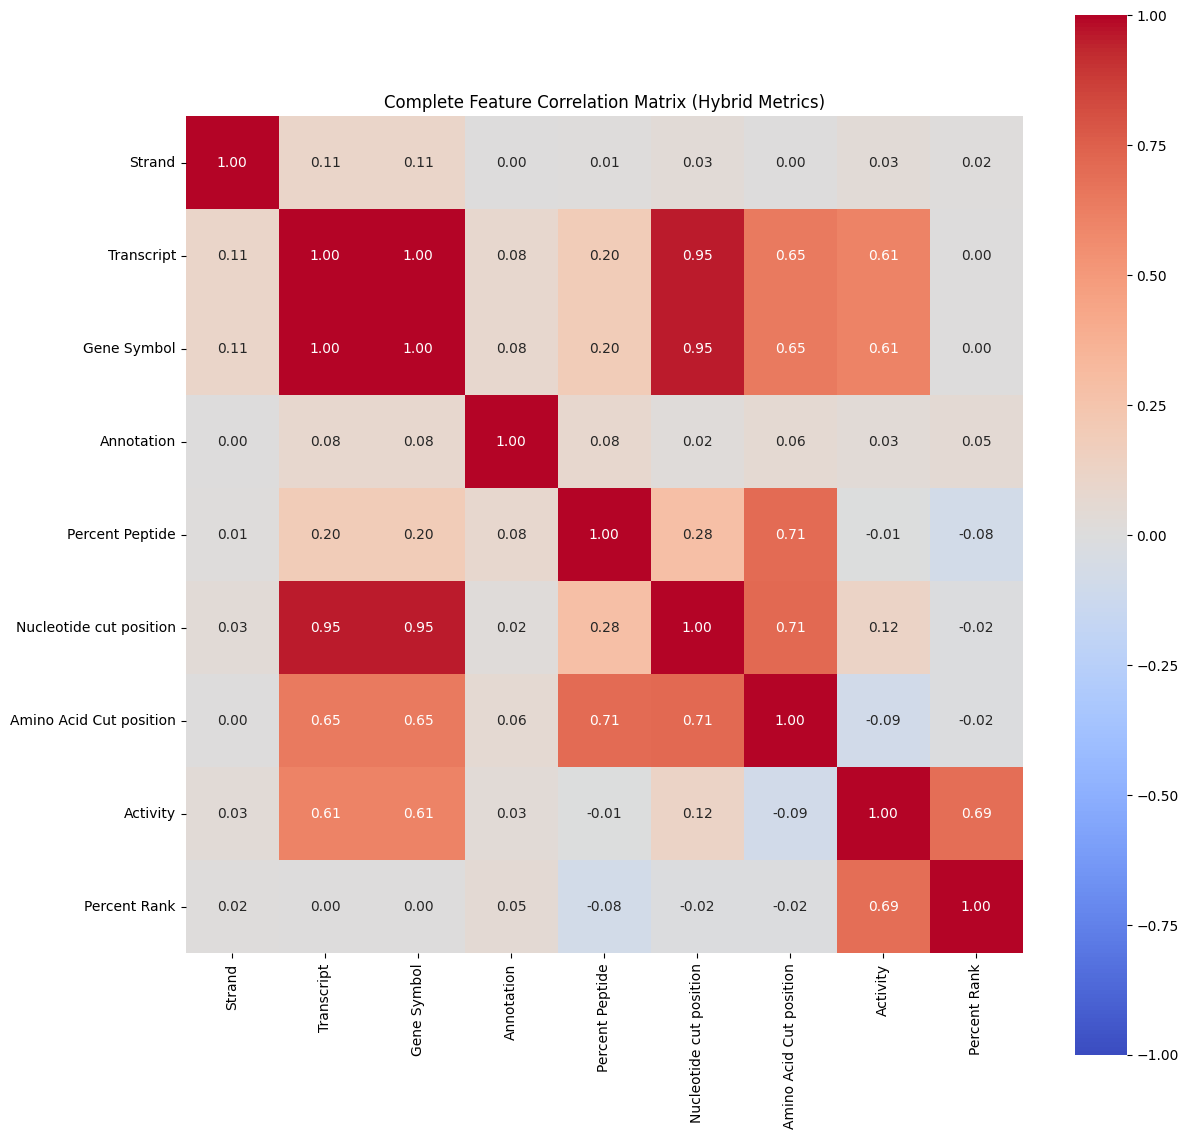

In [46]:
from dython.nominal import associations
import matplotlib.pyplot as plt

# 1. Select the original columns you want to investigate
columns_to_check = [
    'Strand', 'Transcript', 'Gene Symbol', 'Annotation',
    'Percent Peptide', 'Nucleotide cut position', 'Amino Acid Cut position',
    'Activity', 'Percent Rank'
]

# 2. Compute and plot the hybrid correlation matrix automatically
plt.figure(figsize=(12, 10))
associations(
    df[columns_to_check],
    nominal_columns=['Strand', 'Transcript', 'Gene Symbol', 'Annotation'], # Tell it which ones are categorical
    numerical_columns=['Percent Peptide', 'Nucleotide cut position', 'Amino Acid Cut position', 'Activity', 'Percent Rank'],
    title="Complete Feature Correlation Matrix (Hybrid Metrics)",
    cmap="coolwarm"
)
plt.show()

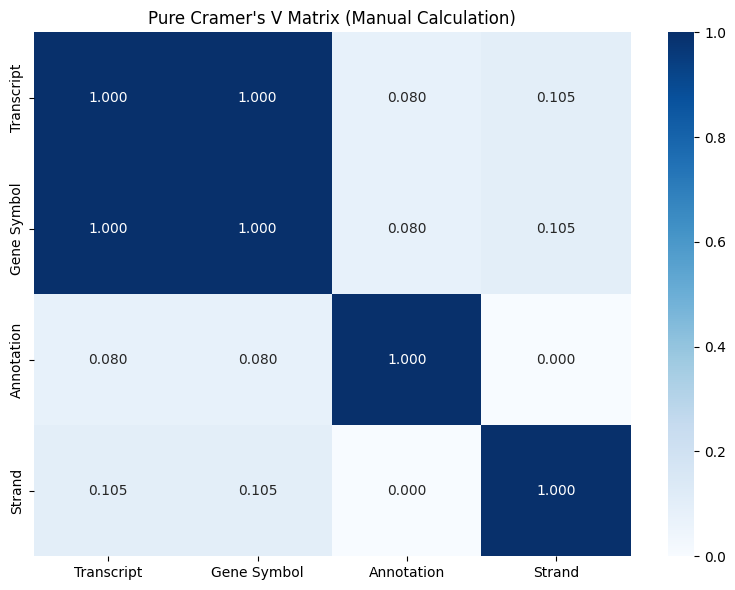

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def calculate_cramers_v(x, y):
    """Calculates Cramér's V for two categorical columns."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    # Avoid division by zero if columns are completely empty
    if n == 0:
        return 0.0

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Apply bias correction for Cramér's V
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    # Check if denominator becomes zero or negative after correction
    denominator = min((k_corr - 1), (r_corr - 1))
    if denominator <= 0:
        return 0.0

    return np.sqrt(phi2_corr / denominator)

# 1. Define your categorical columns
categorical_cols = ['Transcript', 'Gene Symbol', 'Annotation', 'Strand']

# 2. Initialize an empty DataFrame to store the correlation matrix
matrix_size = len(categorical_cols)
cramers_matrix = pd.DataFrame(
    np.zeros((matrix_size, matrix_size)),
    index=categorical_cols,
    columns=categorical_cols
)

# 3. Fill the matrix by looping through pairs
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0  # Perfect correlation with itself
        else:
            score = calculate_cramers_v(df[col1], df[col2])
            cramers_matrix.loc[col1, col2] = score

# 4. Plot the matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    cramers_matrix,
    annot=True,          # Shows the numerical score inside each square
    cmap="Blues",
    vmin=0, vmax=1,      # Forces the scale boundaries from 0 to 1
    fmt=".3f"            # Formats values to 3 decimal places
)
plt.title("Pure Cramer's V Matrix (Manual Calculation)")
plt.tight_layout()
plt.show()

In [48]:
df.describe()

,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Activity,Percent Rank
count,2144.000000,2135.000000,2135.000000,2144.000000,2144.000000
mean,18711.790578,303.029508,47.334014,1.901516,0.502099
std,30899.375678,250.681202,27.950229,1.903784,0.288742
min,56.000000,2.000000,0.180000,-6.603273,0.002198
25%,1052.750000,114.000000,23.510000,0.572749,0.252667
50%,8555.500000,246.000000,47.610000,1.730833,0.502252
75%,15748.750000,402.000000,69.920000,3.635408,0.751337
max,110815.000000,1130.000000,100.000000,6.305269,1.000000


In [49]:
df = df.drop(columns=['Spacer Sequence', 'Transcript', 'Activity'])

In [50]:
df.head()

,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Gene Symbol,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Annotation,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,sense,CD45,242,2.0,0.18,CDS,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,sense,CD45,243,2.0,0.18,CDS,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,antisense,CD45,248,4.0,0.35,CDS,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,sense,CD45,250,5.0,0.44,CDS,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,sense,CD45,263,9.0,0.80,CDS,0.258900


In [51]:
df['Gene Symbol'].unique()

<ArrowStringArray>
['CD45', 'H2-K', 'CD33', 'THY1', 'CD13', 'CD28', 'CD5', 'CD15', 'CD43']
Length: 9, dtype: str

In [52]:
df['Annotation'].unique()

<ArrowStringArray>
['CDS', 'I/CDS', 'CDS/I', 'CDS/3U']
Length: 4, dtype: str

In [53]:
df['Strand'] = df['Strand'].astype(str).str.strip().str.lower()
df['Strand'] = df['Strand'].map({'sense': 1, 'antisense': 0})
df.head()

,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Gene Symbol,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Annotation,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,1,CD45,242,2.0,0.18,CDS,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,1,CD45,243,2.0,0.18,CDS,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,0,CD45,248,4.0,0.35,CDS,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,1,CD45,250,5.0,0.44,CDS,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,1,CD45,263,9.0,0.80,CDS,0.258900


In [54]:
df.rename(columns={'Extended Spacer(NNNN[20nt]NGGNNNNNNN)': 'Spacer'}, inplace=True)


In [55]:
import numpy as np
import pandas as pd

def prepare_final_dataset(df):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}

    dna_list = []
    for seq in df['Spacer']:
        bits = []
        for base in str(seq).upper():
            bits.extend(mapping.get(base, [0,0,0,0]))
        dna_list.append(bits)
    X_dna = np.array(dna_list)

    # 1. One-hot encode your extra categorical columns automatically
    categorical_cols = ['Gene Symbol', 'Annotation']
    numerical_cols = ['Percent Peptide', 'Nucleotide cut position', 'Amino Acid Cut position', 'Strand']

    df_extras_encoded = pd.get_dummies(df[categorical_cols], dtype=float)
    df_extras = pd.concat([df[numerical_cols], df_extras_encoded], axis=1)
    X_extras = df_extras.values

    # 2. Combine the DNA features and the encoded features
    X = np.hstack([X_dna, X_extras])
    y = df['Percent Rank'].values

    # 3. Return the exact structure your model training script expects
    return X, y, X_dna.shape[1]   # Returns the integer width (34 * 4 = 136)

In [56]:
X, y, dna_width = prepare_final_dataset(df)
print(f"X shape: {X.shape}, DNA cols: {dna_width}, Extra cols: {X.shape[1] - dna_width}")

X shape: (2144, 153), DNA cols: 136, Extra cols: 17


In [57]:
# 1. Automatically calculate your DNA positions
n_positions = dna_width // 4   # Dynamically calculates 34 (or 33)

dna_feature_names = [
    f"DNA Pos {i} ({base})"
    for i in range(n_positions)
    for base in ['A', 'C', 'G', 'T']
]

# 2. Replicate the EXACT database column order from your prepare function
categorical_cols = ['Gene Symbol', 'Annotation']
numerical_cols = ['Percent Peptide', 'Nucleotide cut position', 'Amino Acid Cut position', 'Strand']

# Run get_dummies on your original dataframe to see how pandas orders the columns
df_extras_encoded = pd.get_dummies(df[categorical_cols], dtype=float)

# Match the exact concatenation order: numerical columns first, then encoded categoricals
extra_feature_names = numerical_cols + list(df_extras_encoded.columns)

# 3. Combine them
feature_names = dna_feature_names + extra_feature_names

# This assertion will now pass perfectly!
assert len(feature_names) == X.shape[1], \
    f"Mismatch: {len(feature_names)} names vs {X.shape[1]} columns"

X_named = pd.DataFrame(X, columns=feature_names)

In [58]:
X_named.head()

,DNA Pos 0 (A),DNA Pos 0 (C),DNA Pos 0 (G),DNA Pos 0 (T),DNA Pos 1 (A),DNA Pos 1 (C),DNA Pos 1 (G),DNA Pos 1 (T),DNA Pos 2 (A),DNA Pos 2 (C),...,Gene Symbol_CD33,Gene Symbol_CD43,Gene Symbol_CD45,Gene Symbol_CD5,Gene Symbol_H2-K,Gene Symbol_THY1,Annotation_CDS,Annotation_CDS/3U,Annotation_CDS/I,Annotation_I/CDS
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [59]:
# Convert column index to a standard Python list
print(sorted(list(X_named.columns)))


['Amino Acid Cut position', 'Annotation_CDS', 'Annotation_CDS/3U', 'Annotation_CDS/I', 'Annotation_I/CDS', 'DNA Pos 0 (A)', 'DNA Pos 0 (C)', 'DNA Pos 0 (G)', 'DNA Pos 0 (T)', 'DNA Pos 1 (A)', 'DNA Pos 1 (C)', 'DNA Pos 1 (G)', 'DNA Pos 1 (T)', 'DNA Pos 10 (A)', 'DNA Pos 10 (C)', 'DNA Pos 10 (G)', 'DNA Pos 10 (T)', 'DNA Pos 11 (A)', 'DNA Pos 11 (C)', 'DNA Pos 11 (G)', 'DNA Pos 11 (T)', 'DNA Pos 12 (A)', 'DNA Pos 12 (C)', 'DNA Pos 12 (G)', 'DNA Pos 12 (T)', 'DNA Pos 13 (A)', 'DNA Pos 13 (C)', 'DNA Pos 13 (G)', 'DNA Pos 13 (T)', 'DNA Pos 14 (A)', 'DNA Pos 14 (C)', 'DNA Pos 14 (G)', 'DNA Pos 14 (T)', 'DNA Pos 15 (A)', 'DNA Pos 15 (C)', 'DNA Pos 15 (G)', 'DNA Pos 15 (T)', 'DNA Pos 16 (A)', 'DNA Pos 16 (C)', 'DNA Pos 16 (G)', 'DNA Pos 16 (T)', 'DNA Pos 17 (A)', 'DNA Pos 17 (C)', 'DNA Pos 17 (G)', 'DNA Pos 17 (T)', 'DNA Pos 18 (A)', 'DNA Pos 18 (C)', 'DNA Pos 18 (G)', 'DNA Pos 18 (T)', 'DNA Pos 19 (A)', 'DNA Pos 19 (C)', 'DNA Pos 19 (G)', 'DNA Pos 19 (T)', 'DNA Pos 2 (A)', 'DNA Pos 2 (C)', 'DN

In [60]:
import numpy as np

# 1. Check the whole matrix
has_nan = np.isnan(X).any()
print(f"Does X have NaNs? {has_nan}")

# 2. Find exactly where they are (if any)
if has_nan:
    nan_cols = np.where(np.isnan(X).any(axis=0))[0]
    print(f"NaNs found in column indices: {nan_cols}")

    # Quick fix: Replace NaNs with 0 (or the mean of the column)
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

Does X have NaNs? True
NaNs found in column indices: [136 138]


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

continuous_cols = [141, 142, 143]  # change these!

X_train_scaled[:, continuous_cols] = scaler.fit_transform(
    X_train[:, continuous_cols]
)

X_test_scaled[:, continuous_cols] = scaler.transform(
    X_test[:, continuous_cols]
)

In [62]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data is now clean, outlier-checked, and scaled!")

Data is now clean, outlier-checked, and scaled!


In [63]:
X_scaled

array([[ 1.90281099, -0.6168904 , -0.58884095, ..., -0.02160175,
        -0.0374328 , -0.06119901],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.02160175,
        -0.0374328 , -0.06119901],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.02160175,
        -0.0374328 , -0.06119901],
       ...,
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.02160175,
        -0.0374328 , -0.06119901],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.02160175,
        -0.0374328 , -0.06119901],
       [ 1.90281099, -0.6168904 , -0.58884095, ..., -0.02160175,
        -0.0374328 , -0.06119901]], shape=(2144, 153))

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Basic Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = lr_model.predict(X_test)

# Since Percent Rank must be between 0 and 1, we clip any "overflow" predictions
y_pred = np.clip(y_pred, 0, 1)

In [65]:
# Calculate Spearman Correlation
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"--- Model Results ---")
print(f"Spearman Correlation: {spearman_corr:.4f}")
print(f"Mean Absolute Error:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R-squared Score:      {r2_score(y_test, y_pred):.4f}")

--- Model Results ---
Spearman Correlation: 0.4453
Mean Absolute Error:  0.2168
R-squared Score:      0.1787


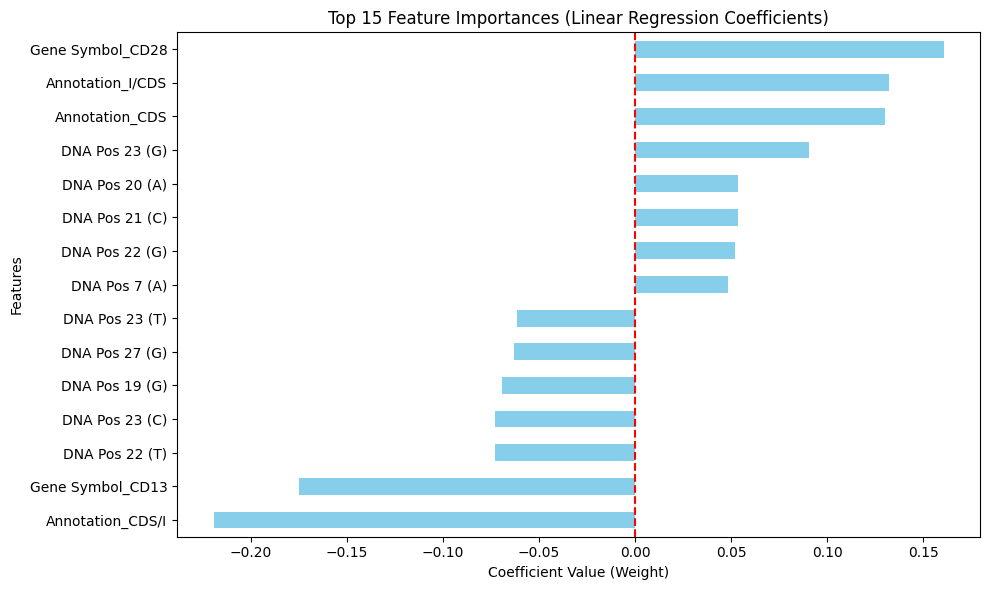

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the absolute values of the coefficients (so negative impact is seen as important too)
# 'lr_model' is your trained LinearRegression() instance
importance = lr_model.coef_

# 2. Match them with your 'feature_names' list from your data prep step
feat_importance = pd.Series(importance, index=feature_names)

# 3. Grab the top 15 most important features so the graph isn't too crowded
# We sort by absolute value to see the strongest drivers overall
top_features = feat_importance.abs().sort_values(ascending=False).head(15)
# Map the original signed values back to the top features for the plot
top_features_signed = feat_importance[top_features.index]

# 4. Graph it!
plt.figure(figsize=(10, 6))
top_features_signed.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 15 Feature Importances (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value (Weight)')
plt.ylabel('Features')
plt.axvline(x=0, color='red', linestyle='--') # Marks the zero line
plt.tight_layout()
plt.show()

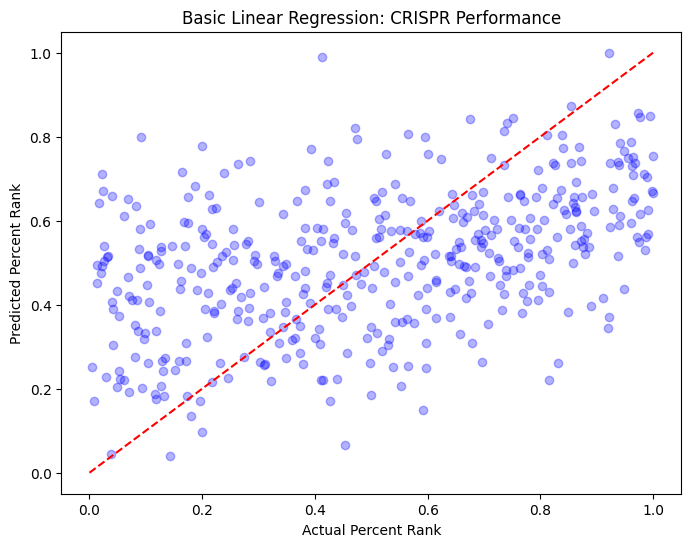

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # The "Perfect Prediction" line
plt.xlabel('Actual Percent Rank')
plt.ylabel('Predicted Percent Rank')
plt.title('Basic Linear Regression: CRISPR Performance')
plt.show()

--- LR Model Results(before) ---  
Spearman Correlation: 0.4262  
Mean Absolute Error:  0.2188  
R-squared Score:      0.1701    


--- Model Results(after, activity) ---  
Spearman Correlation: 0.9338  
Mean Absolute Error:  0.0969  
R-squared Score:      0.8317  


--- Model Results(after, no activity) ---
Spearman Correlation: 0.4453
Mean Absolute Error:  0.2168
R-squared Score:      0.1787

thoughts:  
coud be better, but not a bad start;
definielty room to improve(before)  


now its much better(after)


###lets try xgb

In [68]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# ── 5. Evaluate ───────────────────────────────────────────────────────────────
y_pred = np.clip(xgb_model.predict(X_test), 0, 1)
spearman, _ = spearmanr(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\n--- XGBoost Results ---")
print(f"Spearman Correlation: {spearman:.4f}")
print(f"Mean Absolute Error:  {mae:.4f}")


--- XGBoost Results ---
Spearman Correlation: 0.6826
Mean Absolute Error:  0.1687


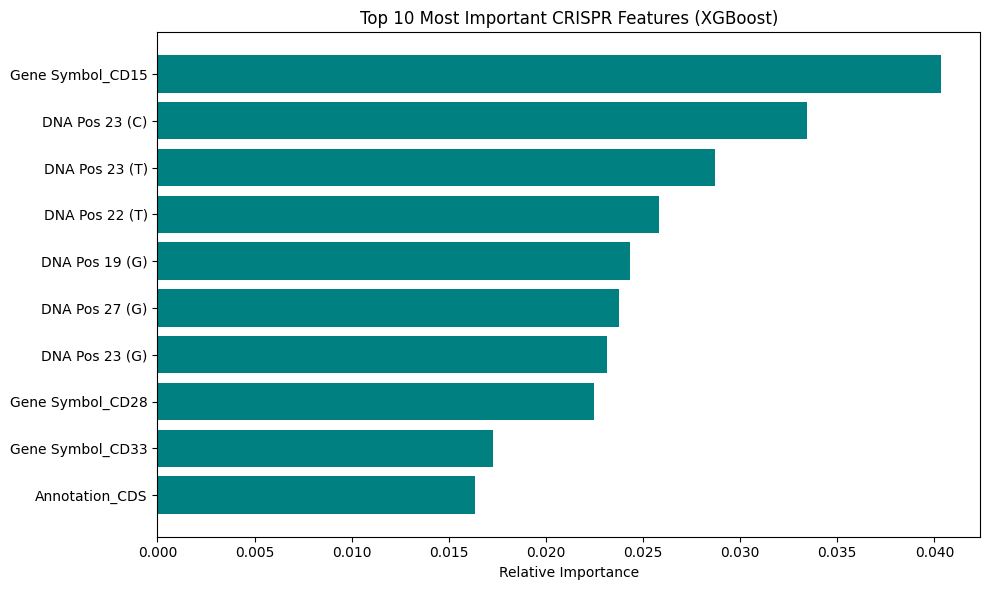

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the raw feature importance from XGBoost
importances = xgb_model.feature_importances_

# 2. Get the indices of the top 10 features, sorted from smallest to largest
indices = np.argsort(importances)[-10:]

# 3. Map those indices to your actual feature_names list
# This creates a list of the 10 real names matching the top indices
top_feature_names = [feature_names[i] for i in indices]

# 4. Plot it!
plt.figure(figsize=(10, 6))
plt.title("Top 10 Most Important CRISPR Features (XGBoost)")

# Draw the horizontal bars
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')

# Use the real feature names for the y-axis labels
plt.yticks(range(len(indices)), top_feature_names)

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

--- XGBoost Model Results(before) ---  
Spearman Correlation: 0.5750  
Mean Absolute Error:  0.1934  



--- XGBoost Results(after) ---  
Spearman Correlation: 0.9988  
Mean Absolute Error:  0.0099  


--- XGBoost Results(after, no activity) ---  
Spearman Correlation: 0.6826  
Mean Absolute Error:  0.1687  

thoughts:  
better thean lr - expected  
still room to improve(before)  

even better wow; i dont even think we need to try neural network, sicne it was laready worse the first time(after)

##lets try nn now

In [70]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from scipy.stats import spearmanr

# Build the model
nn_model = models.Sequential([
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(1)
])

# Compile
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Train
history = nn_model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predict
y_pred_nn = nn_model.predict(X_test, verbose=0).flatten()

# Evaluate
spearman_final, p_value = spearmanr(y_test, y_pred_nn)

print("\n--- Final Results ---")
print(f"Final Spearman Correlation: {spearman_final:.4f}")
print(f"P-value: {p_value:.4e}")

Epoch 1/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7915 - mae: 0.6250 - val_loss: 1.0913 - val_mae: 0.6676 - learning_rate: 0.0010
Epoch 2/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5744 - mae: 0.5236 - val_loss: 0.8002 - val_mae: 0.5662 - learning_rate: 0.0010
Epoch 3/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4946 - mae: 0.4964 - val_loss: 0.3028 - val_mae: 0.3937 - learning_rate: 0.0010
Epoch 4/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4182 - mae: 0.4577 - val_loss: 0.1772 - val_mae: 0.3308 - learning_rate: 0.0010
Epoch 5/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3560 - mae: 0.4271 - val_loss: 0.1219 - val_mae: 0.2740 - learning_rate: 0.0010
Epoch 6/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3194 - mae: 0.4054 - val_loss: 0.0990 - val_mae: 0.2501 - learning_rate: 0.0010
Epoch 7/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2635 - mae: 0.3822 - val_loss: 0.1072 - val_mae: 0.2589 - learning_rate: 0.0010
Epoch 8/200


with a 256, 128, 64, 16, we got 0.55  
with a 256, 128, 128, 64, 16, we got 0.5  
with a 256, 128, 64, 32, 16, we got 0.52  
with a 512, 256, 64, 32, 16, we got .52   
with 512, 128, 32, 32, 16, we got 0.5  
with a 256, 256, 128, 64, 32, we got 0.54

with 256, 256, 128, 64, 32, we got 0.53(rmsprop)

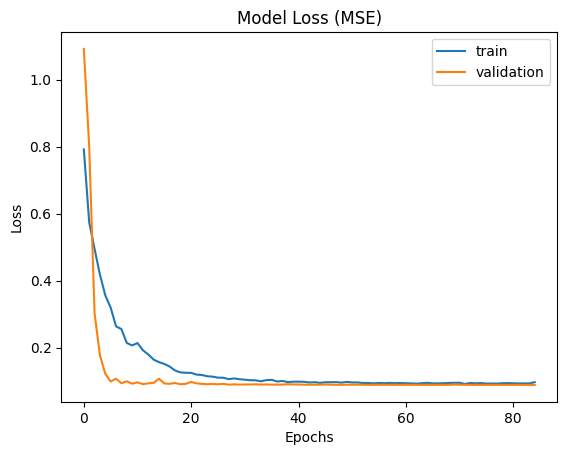

In [71]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [72]:
print("Prediction std:", y_pred.std())
print("Prediction min/max:", y_pred.min(), y_pred.max())
print("First 10 preds:", y_pred[:10])
print("First 10 actual:", y_test[:10])

Prediction std: 0.17746298
Prediction min/max: 0.08484097 0.92187375
First 10 preds: [0.7288056  0.6392784  0.41135043 0.34721953 0.5963711  0.6532682
 0.56991696 0.4612929  0.44340688 0.5047193 ]
First 10 actual: [0.96603774 0.88679245 0.37864078 0.11640212 0.87472527 0.80377358
 0.66850829 0.22099447 0.20942408 0.24919094]


In [73]:
from scipy.stats import spearmanr

preds = [0.7288056,0.6392784,0.41135043,0.34721953,0.5963711,
         0.6532682,0.56991696,0.4612929,0.44340688,0.5047193]

actual = [0.96603774,0.88679245,0.37864078,0.11640212,0.87472527,
          0.80377358,0.66850829,0.22099447,0.20942408,0.24919094]

print(spearmanr(actual, preds))

SignificanceResult(statistic=np.float64(0.8909090909090909), pvalue=np.float64(0.0005421442248338665))


In [74]:
print(type(y_test))
print(type(y_pred))

print(y_test.shape)
print(y_pred.shape)

print(spearmanr(y_test[:10], y_pred[:10]))
print(spearmanr(y_test, y_pred))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(429,)
(429,)
SignificanceResult(statistic=np.float64(0.8909090909090909), pvalue=np.float64(0.0005421442248338665))
SignificanceResult(statistic=np.float64(0.6826114689542911), pvalue=np.float64(3.8763585909789126e-60))


In [75]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(X_train[:2])
print(y_train[:10])

(1715, 153)
(429, 153)
(1715,)
(429,)
[[0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 1.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 1.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 1.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 1.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00
  0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 1.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+

--- Improved Neural Network Results ---  
Spearman Correlation: 0.5124

thoughts:  
nn didnt have enough data to run well  
xgboost was the best, so lets try and run shap on the xgb model

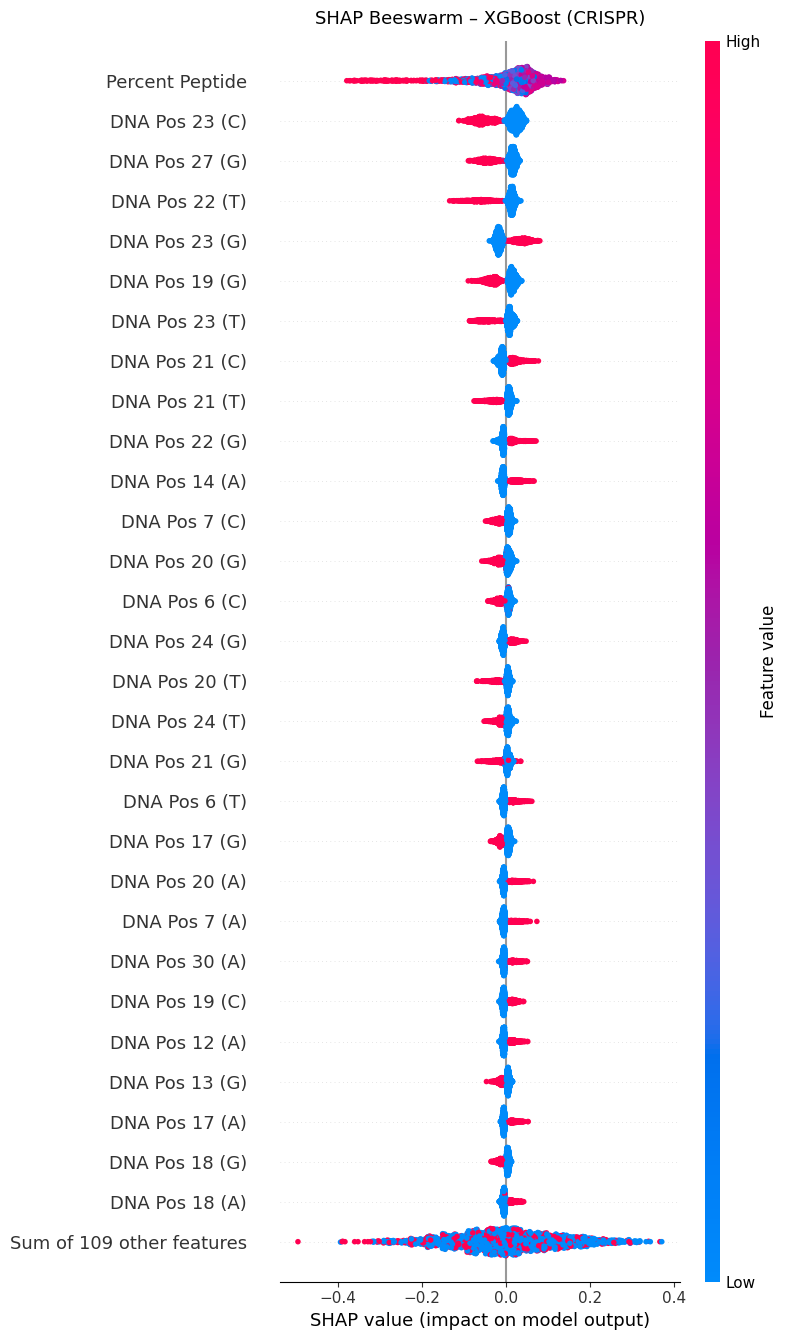

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Wrap X in a named DataFrame
n_positions = 34
dna_feature_names = [
    f"DNA Pos {i} ({base})"
    for i in range(n_positions)
    for base in ['A', 'C', 'G', 'T']
]
feature_names = dna_feature_names + ['Percent Peptide', 'Strand']

X_named = pd.DataFrame(X, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_named)

# Plot
plt.figure()
shap.plots.beeswarm(shap_values, max_display=30, show=False)
plt.title("SHAP Beeswarm – XGBoost (CRISPR)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

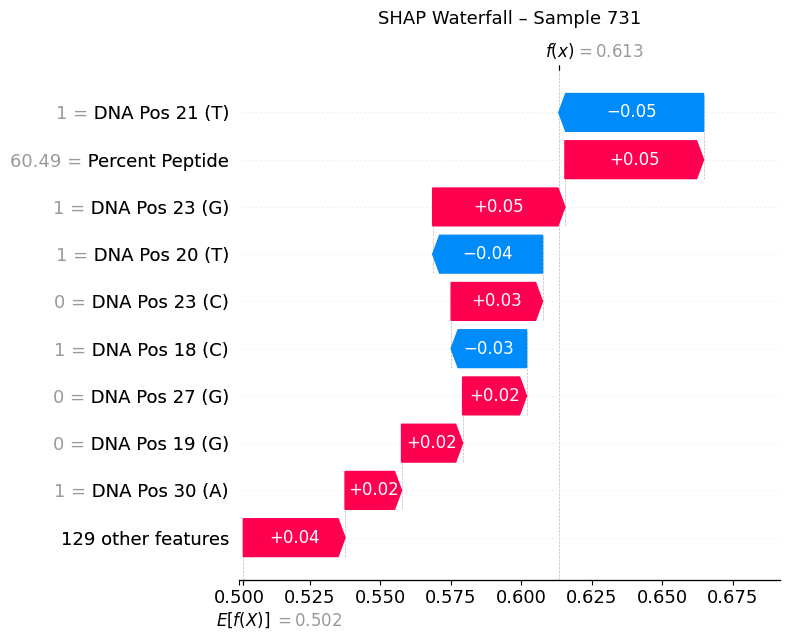

Saved → waterfall_sample_731.png


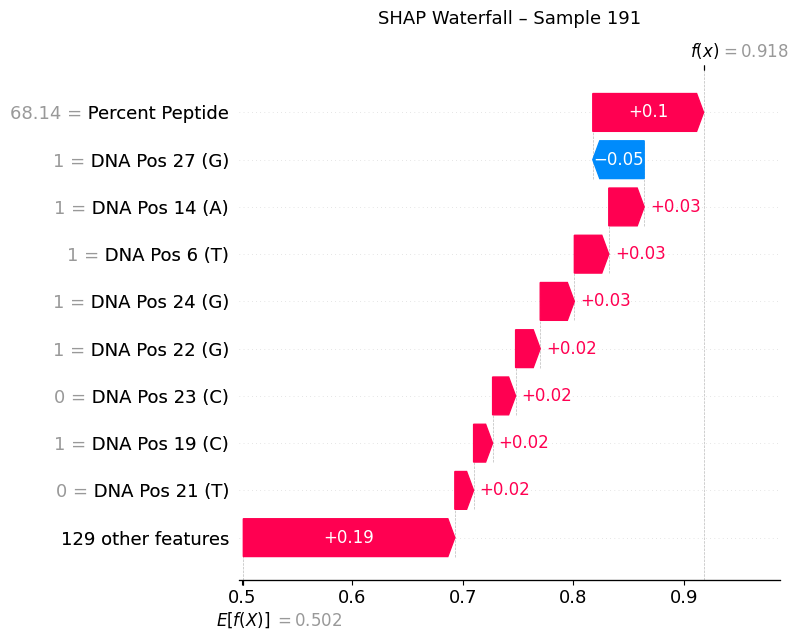

Saved → waterfall_sample_191.png


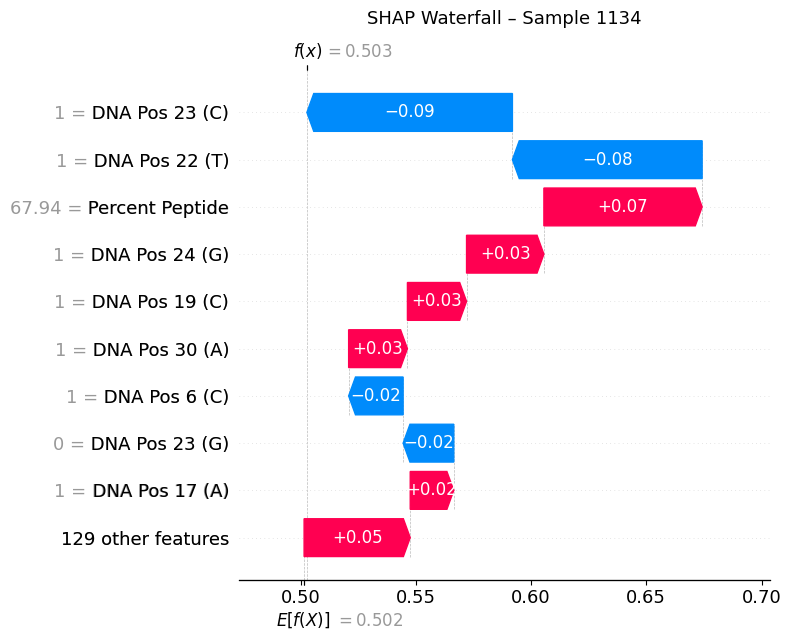

Saved → waterfall_sample_1134.png


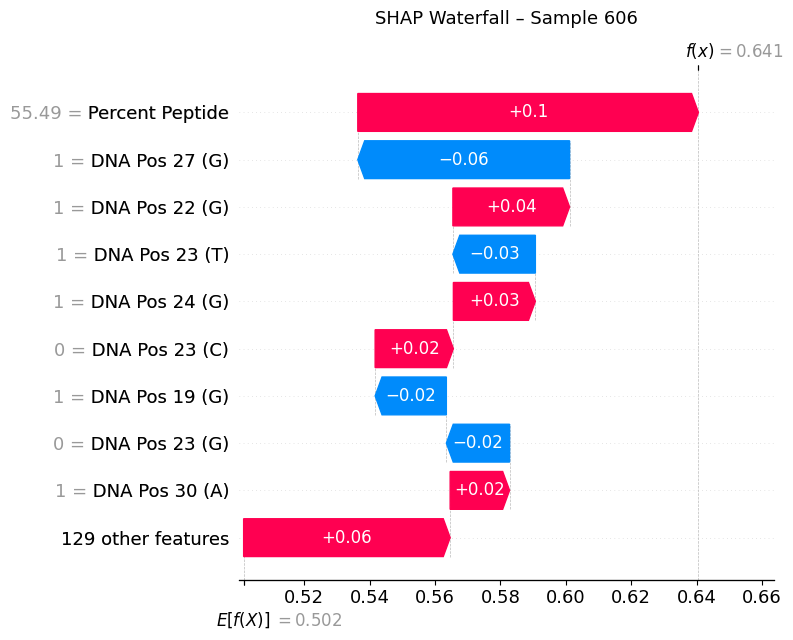

Saved → waterfall_sample_606.png


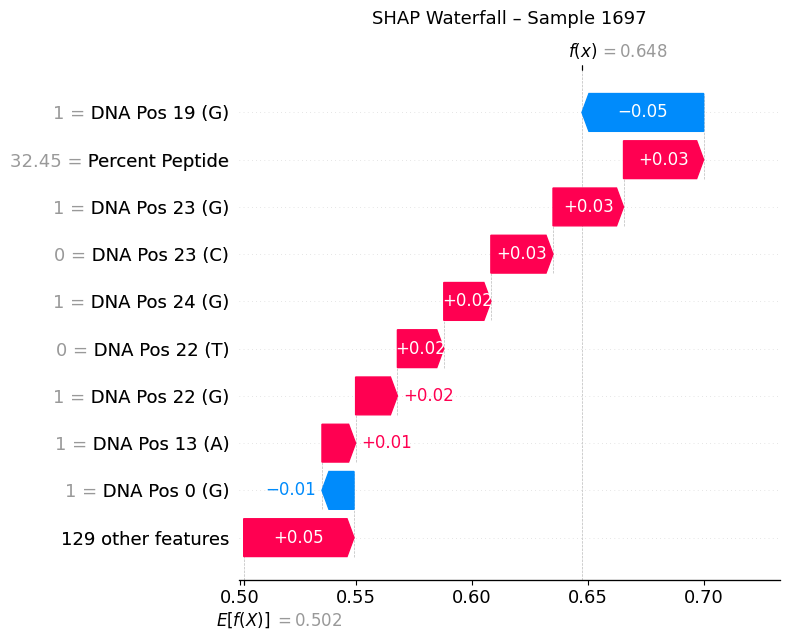

Saved → waterfall_sample_1697.png


In [ ]:
import random

# Pick a few random samples
sample_indices = random.sample(range(len(X_named)), 5)  # change 5 to however many you want

for idx in sample_indices:
    plt.figure()
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.title(f"SHAP Waterfall – Sample {idx}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"waterfall_sample_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → waterfall_sample_{idx}.png")